# 🔢 Demo — Similaridade Vetorial

**Objetivo:** Visualizar vetores no plano 2D e calcular a similaridade entre eles usando produto escalar (dot product).

---

Bibliotecas utilizadas:
- `numpy` → criação e operações com vetores
- `matplotlib.pyplot` → visualização gráfica

## 1. Importando as bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Definindo os vetores

Imagine que cada vetor representa um **destino de viagem** descrito por duas características:

| Dimensão | Significado        |
|----------|--------------------|
| `x`      | nível de praia     |
| `y`      | nível de aventura  |

- **Cancún** → muita praia, pouca aventura  
- **Maldivas** → muita praia, pouca aventura (parecido com Cancún!)  
- **Patagônia** → pouca praia, muita aventura (bem diferente)

In [11]:
# Cada vetor tem 2 dimensões: [praia, aventura]
cancun    = np.array([0.9, 0.2])   # muita praia, pouca aventura
maldivas  = np.array([0.8, 0.3])   # muita praia, pouca aventura — parecido com Cancún
patagonia = np.array([0.1, 0.9])   # pouca praia, muita aventura — bem diferente

print("Cancún    :", cancun)
print("Maldivas  :", maldivas)
print("Patagônia :", patagonia)

Cancún    : [0.9 0.2]
Maldivas  : [0.8 0.3]
Patagônia : [0.1 0.9]


## 3. Visualizando os vetores

Cada vetor é desenhado como uma **seta saindo da origem (0, 0)**.

Vetores que apontam para a mesma direção = destinos parecidos.

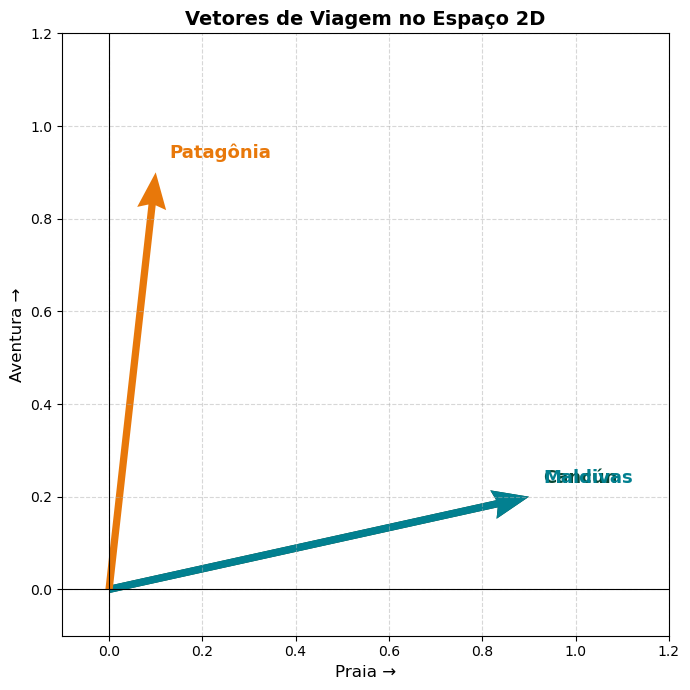

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))

# --- desenhando os vetores como setas a partir da origem ---
vetores = [
    (cancun,    "Cancún",    "#084734"),
    (maldivas,  "Maldivas",  "#028090"),
    (patagonia, "Patagônia", "#E8780A"),
]

for vetor, nome, cor in vetores:
    ax.quiver(
        0, 0,           # ponto de origem
        vetor[0],       # componente x
        vetor[1],       # componente y
        angles="xy", scale_units="xy", scale=1,
        color=cor, width=0.012, headwidth=4
    )
    # rótulo um pouco além da ponta da seta
    ax.text(
        vetor[0] + 0.03,
        vetor[1] + 0.03,
        nome,
        fontsize=13, fontweight="bold", color=cor
    )

# --- configurações do gráfico ---
plt.xlim(-0.1, 1.2)          # limite do eixo x
plt.ylim(-0.1, 1.2)          # limite do eixo y
plt.grid(True, linestyle="--", alpha=0.5)

ax.set_xlabel("Praia →",    fontsize=12)
ax.set_ylabel("Aventura →", fontsize=12)
ax.set_title("Vetores de Viagem no Espaço 2D", fontsize=14, fontweight="bold")

# linha de referência nos eixos
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

## 4. Calculando a Similaridade com `np.dot`


In [ ]:
# --- calculando a similaridade com np.dot ---
sim_cancun_maldivas  = np.dot(cancun_n, maldivas_n)
sim_cancun_patagonia = np.dot(cancun_n, patagonia_n)
sim_maldivas_patagonia = np.dot(maldivas_n, patagonia_n)

print("Similaridade (dot product entre vetores normalizados):")
print()
print(f"  Cancún    × Maldivas  = {sim_cancun_maldivas:.4f}  ← muito similar (mesma direção)")
print(f"  Cancún    × Patagônia = {sim_cancun_patagonia:.4f}  ← pouco similar (direções opostas)")
print(f"  Maldivas  × Patagônia = {sim_maldivas_patagonia:.4f}  ← pouco similar (direções opostas)")

Similaridade (dot product entre vetores normalizados):

  Cancún    × Maldivas  = 0.9902  ← muito similar (mesma direção)
  Cancún    × Patagônia = 0.3234  ← pouco similar (direções opostas)
  Maldivas  × Patagônia = 0.4524  ← pouco similar (direções opostas)


## 5. Visualizando a Similaridade em Barras

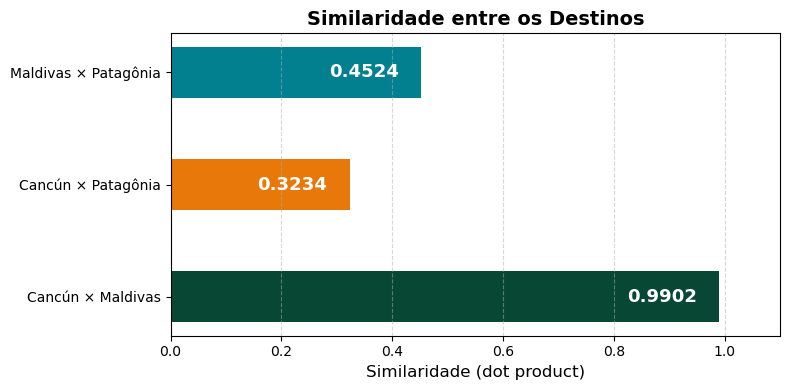

In [6]:
pares  = ["Cancún × Maldivas", "Cancún × Patagônia", "Maldivas × Patagônia"]
scores = [sim_cancun_maldivas, sim_cancun_patagonia, sim_maldivas_patagonia]
cores  = ["#084734", "#E8780A", "#028090"]

fig, ax = plt.subplots(figsize=(8, 4))

barras = ax.barh(pares, scores, color=cores, height=0.45)

# valor dentro de cada barra
for barra, score in zip(barras, scores):
    ax.text(
        score - 0.04,
        barra.get_y() + barra.get_height() / 2,
        f"{score:.4f}",
        va="center", ha="right",
        color="white", fontsize=13, fontweight="bold"
    )

plt.xlim(0, 1.1)
plt.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_xlabel("Similaridade (dot product)", fontsize=12)
ax.set_title("Similaridade entre os Destinos", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## 6. Resumo

| Par                       | Similaridade | Interpretação                          |
|---------------------------|:------------:|----------------------------------------|
| Cancún × Maldivas         | ~0.99        | Quase idênticos — ambos são praia      |
| Cancún × Patagônia        | ~0.36        | Bem diferentes — praia vs aventura     |
| Maldivas × Patagônia      | ~0.43        | Bem diferentes — praia vs aventura     |

---

### O que isso significa em um banco de dados vetorizado?

Em vez de 2 dimensões (praia e aventura), um modelo real usa **384 ou 1536 dimensões** para capturar muito mais nuances.  
O processo é o mesmo:

```
dado bruto  →  modelo de embedding  →  vetor de N dimensões  →  comparação com dot product / cosine
```

Quando você faz uma busca semântica, o banco:
1. Converte sua query em vetor
2. Calcula a similaridade com todos os vetores armazenados
3. Retorna os mais próximos — exatamente como vimos aqui com `np.dot`